In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import re

import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, accuracy_score

In [3]:
df = pd.read_csv('D:\Movie-sentiment\IMDB Dataset.csv')
df.head()

<>:1: SyntaxWarning: invalid escape sequence '\M'
<>:1: SyntaxWarning: invalid escape sequence '\M'
C:\Users\ankit\AppData\Local\Temp\ipykernel_3328\2811938238.py:1: SyntaxWarning: invalid escape sequence '\M'
  df = pd.read_csv('D:\Movie-sentiment\IMDB Dataset.csv')


,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [4]:
print(df.shape)
print(df['sentiment'].value_counts())

(50000, 2)
sentiment
positive    25000
negative    25000
Name: count, dtype: int64


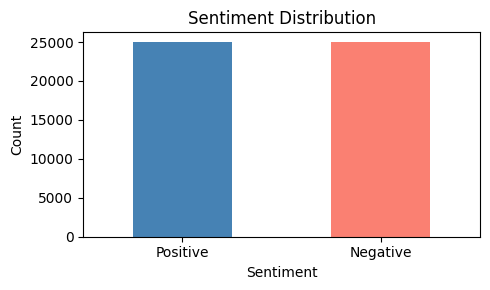

In [5]:
fig, ax = plt.subplots(figsize=(5, 3))
df['sentiment'].value_counts().plot(kind='bar', color=['steelblue', 'salmon'], ax=ax)
ax.set_title('Sentiment Distribution')
ax.set_xlabel('Sentiment')
ax.set_ylabel('Count')
ax.set_xticklabels(['Positive', 'Negative'], rotation=0)
plt.tight_layout()
plt.show()

In [6]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r'<.*?>', '', text)
    text = re.sub(r'[^a-zA-Z ]', '', text)
    return text

df['review'] = df['review'].apply(clean_text)
df['sentiment'] = df['sentiment'].map({'positive': 1, 'negative': 0})
df.head()

,review,sentiment
0,one of the other reviewers has mentioned that ...,1
1,a wonderful little production the filming tech...,1
2,i thought this was a wonderful way to spend ti...,1
3,basically theres a family where a little boy j...,0
4,petter matteis love in the time of money is a ...,1


In [7]:
vocab_size = 10000
max_length = 200

tokenizer = Tokenizer(num_words=vocab_size)
tokenizer.fit_on_texts(df['review'])

X = tokenizer.texts_to_sequences(df['review'])
X = pad_sequences(X, maxlen=max_length)
y = df['sentiment'].values

print('X shape:', X.shape)
print('y shape:', y.shape)

Executing <Task pending name='Task-1' coro=<IOPubThread._run_event_pipe_gc() running at d:\Movie-sentiment\venv\Lib\site-packages\ipykernel\iostream.py:193> wait_for=<Future pending cb=[Task.task_wakeup()] created at d:\Movie-sentiment\venv\Lib\asyncio\base_events.py:427> created at d:\Movie-sentiment\venv\Lib\asyncio\tasks.py:685> took 0.187 seconds
Executing <Handle BaseAsyncIOLoop._handle_events(1116, 1) created at d:\Movie-sentiment\venv\Lib\asyncio\selector_events.py:276> took 0.250 seconds


X shape: (50000, 200)
y shape: (50000,)


In [8]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print('Train size:', X_train.shape[0])
print('Test size:', X_test.shape[0])

Train size: 40000
Test size: 10000


In [9]:
model = Sequential([
    Embedding(input_dim=vocab_size, output_dim=128, input_length=max_length),
    LSTM(64),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model.summary()

d:\Movie-sentiment\venv\Lib\site-packages\keras\src\layers\core\embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [10]:
history = model.fit(
    X_train, y_train,
    epochs=10,
    batch_size=64,
    validation_split=0.2
)

Epoch 1/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 24s 46ms/step - accuracy: 0.8132 - loss: 0.4084 - val_accuracy: 0.8634 - val_loss: 0.3216
Epoch 2/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 22s 45ms/step - accuracy: 0.9009 - loss: 0.2556 - val_accuracy: 0.8670 - val_loss: 0.3243
Epoch 3/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 20s 40ms/step - accuracy: 0.9241 - loss: 0.2017 - val_accuracy: 0.8666 - val_loss: 0.3251
Epoch 4/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 20s 40ms/step - accuracy: 0.9429 - loss: 0.1537 - val_accuracy: 0.8715 - val_loss: 0.3870
Epoch 5/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 20s 40ms/step - accuracy: 0.9558 - loss: 0.1247 - val_accuracy: 0.8698 - val_loss: 0.4445
Epoch 6/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 22s 43ms/step - accuracy: 0.9606 - loss: 0.1127 - val_accuracy: 0.8644 - val_loss: 0.4307
Epoch 7/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 21s 42ms/step - accuracy: 0.9771 - loss: 0.0700 - val_accuracy: 0.8700 - val_loss: 0.5072
Epoch 8/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 21s 42ms/step - accuracy: 0.9783 - loss: 0.0647 - 

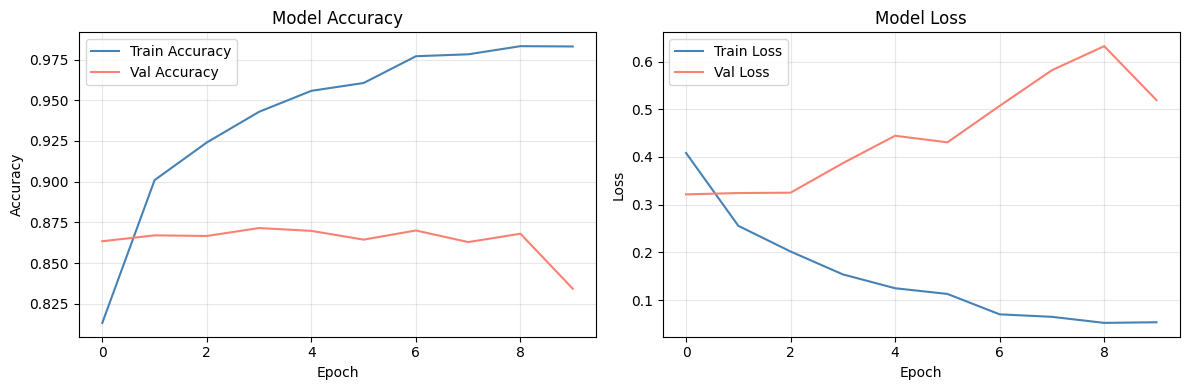

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history.history['accuracy'], label='Train Accuracy', color='steelblue')
axes[0].plot(history.history['val_accuracy'], label='Val Accuracy', color='salmon')
axes[0].set_title('Model Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(history.history['loss'], label='Train Loss', color='steelblue')
axes[1].plot(history.history['val_loss'], label='Val Loss', color='salmon')
axes[1].set_title('Model Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [12]:
loss, accuracy = model.evaluate(X_test, y_test)
print(f'Test Loss: {loss:.4f}')
print(f'Test Accuracy: {accuracy:.4f}')

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.8337 - loss: 0.5087
Test Loss: 0.5087
Test Accuracy: 0.8337


313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step


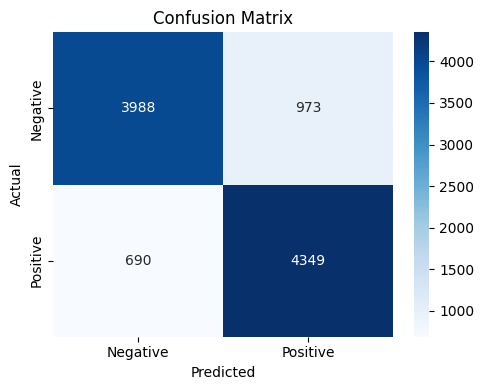

Accuracy Score: 0.8337


In [13]:
y_pred = (model.predict(X_test) > 0.5).astype(int)

cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Negative', 'Positive'],
            yticklabels=['Negative', 'Positive'], ax=ax)
ax.set_title('Confusion Matrix')
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
plt.tight_layout()
plt.show()

print(f'Accuracy Score: {accuracy_score(y_test, y_pred):.4f}')

In [14]:
model.save('sentiment_rnn.h5')

with open('tokenizer.pkl', 'wb') as f:
    pickle.dump(tokenizer, f)

print('Model and tokenizer saved successfully!')
print('Files created: sentiment_rnn.keras, tokenizer.pkl')

Model and tokenizer saved successfully!
Files created: sentiment_rnn.keras, tokenizer.pkl
